In [ ]:
Objective: The main objective of this project is to design and implement a robust data
preprocessing system that addresses common challenges such as missing values, outliers,
inconsistent formatting, and noise.
By performing effective data preprocessing, the project aims to enhance the quality, reliability,
and usefulness of the data for machine learning.
Dataset:
https://drive.google.com/file/d/1F3lRf32JM8ejnXq-Cbf9y7fa57zSHGz_/view?usp=sharing
Key Components to be fulfilled:
1. Data Exploration: (Score : 2)
● Explore the data, list down the unique values in each feature and find its length.
● Perform the statistical analysis and renaming of the columns.
2. Data Cleaning: (Score : 2)
● Find the missing and inappropriate values, treat them appropriately.
● Remove all duplicate rows.
● Find the outliers.
● Replace the value 0 in age as NaN Treat the null values in all columns using any
measures(removing/ replace the values with mean/median/mode) .

3. Data Analysis: (Score : 2)
● Filter the data with age >40 and salary<5000 Plot the chart with age and salary
Count the number of people from each place and represent it visually

4. Data Encoding: (Score : 2)
● Convert categorical variables into numerical representations using techniques
such as one-hot encoding, label encoding, making them suitable for analysis by
machine learning algorithms.
5. Feature Scaling: (Score : 2)
● After the process of encoding, perform the scaling of the features using
standardscaler and minmaxscaler.

Total Score : 10

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Employee.csv")

In [3]:
df.head()

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


# 1. Data Exploration: (Score : 2)
# ● Explore the data, list down the unique values in each feature and find its length.

In [4]:
for col in df.columns:
    print("Feature Name:" , col)
    print("Unique Values:" , df[col].unique())
    print("Length of Feature:", df[col].nunique())

Feature Name: Company
Unique Values: ['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']
Length of Feature: 6
Feature Name: Age
Unique Values: [20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]
Length of Feature: 29
Feature Name: Salary
Unique Values: [  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]
Length of Feature: 40
Feature Name: Place
Unique Values: ['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']
Length of Feature: 11
Feature Name: Country
Unique Values: ['India']
Length of Feature: 1
Feature Name: Gender
Unique Values: [0 1]
Length of Feature: 2


# ● Perform the statistical analysis and renaming of the columns.

In [5]:
df.describe(include='all')

,Company,Age,Salary,Place,Country,Gender
count,140,130.000000,124.000000,134,148,148.000000
unique,6,NaN,NaN,11,1,NaN
top,TCS,NaN,NaN,Mumbai,India,NaN
freq,53,NaN,NaN,37,148,NaN
mean,NaN,30.484615,5312.467742,NaN,NaN,0.222973
std,NaN,11.096640,2573.764683,NaN,NaN,0.417654
min,NaN,0.000000,1089.000000,NaN,NaN,0.000000
25%,NaN,22.000000,3030.000000,NaN,NaN,0.000000
50%,NaN,32.500000,5000.000000,NaN,NaN,0.000000
75%,NaN,37.750000,8000.000000,NaN,NaN,0.000000


In [6]:
df.columns

Index(['Company', 'Age', 'Salary', 'Place', 'Country', 'Gender'], dtype='object')

In [7]:
df.rename(columns=
    {'Age':'age',
    'Company': 'company',
     'Salary': 'salary',
     'Place' : 'place',
     'Country' : 'country',
     'Gender' : 'gender'
    }, inplace = True)

In [8]:
df.columns

Index(['company', 'age', 'salary', 'place', 'country', 'gender'], dtype='object')

# 2. Data Cleaning: (Score : 2)
# ● Find the missing and inappropriate values, treat them appropriately.

In [9]:
df.isna().sum()

company     8
age        18
salary     24
place      14
country     0
gender      0
dtype: int64

In [10]:
# Negative ages, impossible salaries, strange categories
df[(df['age'] < 0) | (df['salary'] < 0)]


,company,age,salary,place,country,gender


# ● Remove all duplicate rows.


In [11]:
df = df.drop_duplicates()

In [12]:
df

,company,age,salary,place,country,gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0
...,...,...,...,...,...,...
142,Infosys Pvt Lmt,22.0,8202.0,Mumbai,India,0
143,TCS,33.0,9024.0,Calcutta,India,1
145,Infosys,44.0,4034.0,Delhi,India,1
146,TCS,33.0,5034.0,Mumbai,India,1


# ● Find the outliers.

In [13]:
df2 = df.select_dtypes(include='number')
Q1 = df2.quantile(0.25)
Q3 = df2.quantile(0.75)
IQR = Q3 - Q1

outlier = df [ (df2 < (Q1 - 1.5 * IQR)) | (df2 > (Q3 + 1.5 * IQR)).any(axis=1)]

In [14]:
outlier

,company,age,salary,place,country,gender
0,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
142,NaN,NaN,NaN,NaN,NaN,NaN
143,NaN,NaN,NaN,NaN,NaN,NaN
145,NaN,NaN,NaN,NaN,NaN,NaN
146,NaN,NaN,NaN,NaN,NaN,NaN


# Replace the value 0 in age as NaN Treat the null values in all columns using any measures(removing/ replace the values with mean/median/mode) .


In [15]:
df['age'] = df['age'].replace(0, np.nan)

In [16]:
df['age'] = df['age'].fillna(df['age'].median())
df['salary'] = df['salary'].fillna(df['salary'].mean())


In [17]:
df

,company,age,salary,place,country,gender
0,TCS,20.0,5283.471074,Chennai,India,0
1,Infosys,30.0,5283.471074,Mumbai,India,0
2,TCS,35.0,2300.000000,Calcutta,India,0
3,Infosys,40.0,3000.000000,Delhi,India,0
4,TCS,23.0,4000.000000,Mumbai,India,0
...,...,...,...,...,...,...
142,Infosys Pvt Lmt,22.0,8202.000000,Mumbai,India,0
143,TCS,33.0,9024.000000,Calcutta,India,1
145,Infosys,44.0,4034.000000,Delhi,India,1
146,TCS,33.0,5034.000000,Mumbai,India,1


In [18]:
for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna(df[col].mode()[0])
    print(col)

company
place
country


In [19]:
df['company']

0                  TCS
1              Infosys
2                  TCS
3              Infosys
4                  TCS
            ...       
142    Infosys Pvt Lmt
143                TCS
145            Infosys
146                TCS
147            Infosys
Name: company, Length: 144, dtype: object

# 3. Data Analysis: (Score : 2)
# ● Filter the data with age >40 and salary<5000 Plot the chart with age and salary
# Count the number of people from each place and represent it visually


In [20]:
df_filtered = df [ (df['age'] > 40) & (df['salary'] < 5000)]

In [21]:
df_filtered

,company,age,salary,place,country,gender
21,Infosys,50.0,3184.0,Delhi,India,0
32,Infosys,45.0,4034.0,Calcutta,India,0
39,Infosys,41.0,3000.0,Mumbai,India,0
50,Infosys,41.0,3000.0,Chennai,India,0
57,Infosys,51.0,3184.0,Hyderabad,India,0
68,Infosys,43.0,4034.0,Mumbai,India,0
75,Infosys,44.0,3000.0,Cochin,India,0
86,Infosys,41.0,3000.0,Delhi,India,0
93,Infosys,54.0,3184.0,Mumbai,India,0
104,Infosys,44.0,4034.0,Delhi,India,0


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

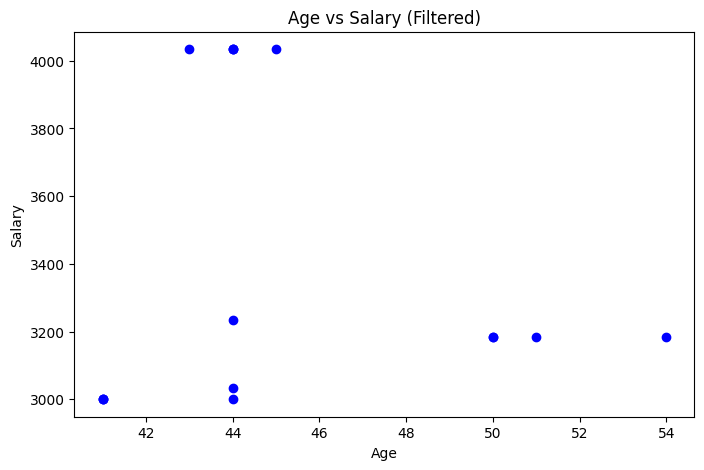

In [23]:
plt.figure(figsize=(8,5))
plt.scatter(df_filtered['age'], df_filtered['salary'], color='blue')
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary (Filtered)")
plt.show()


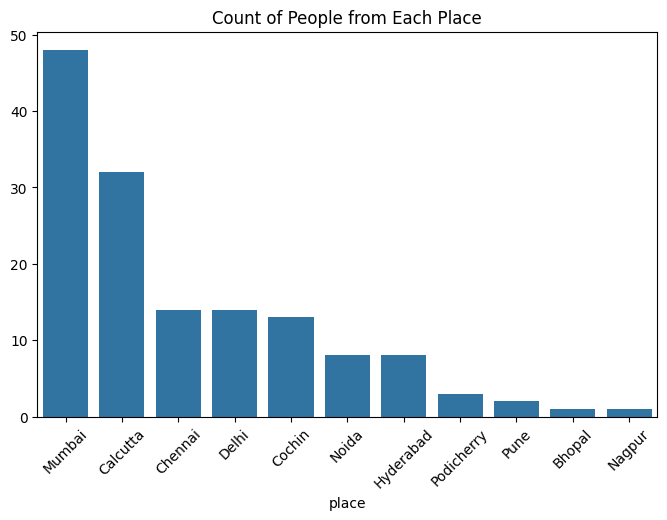

In [29]:
place_counts = df['place'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=place_counts.index, y=place_counts.values)
plt.title("Count of People from Each Place")
plt.xticks(rotation=45)
plt.show()



# 4. Data Encoding: (Score : 2)
# ● Convert categorical variables into numerical representations using techniques such as one-hot encoding, label encoding, making them suitable for analysis by machine learning algorithms.


In [35]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# Label Encode all categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,company,age,salary,place,country,gender
0,4,20.0,5283.471074,2,0,0
1,2,30.0,5283.471074,6,0,0
2,4,35.0,2300.000000,1,0,0
3,2,40.0,3000.000000,4,0,0
4,4,23.0,4000.000000,6,0,0


In [41]:
#df_ohe = pd.get_dummies(df, drop_first=True)
#df_ohe.head()

In [34]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
import pandas as pd

cat_cols = df.select_dtypes(include=['object']).columns

ohe = OneHotEncoder(drop='first', sparse_output=False)  # drop first to avoid dummy trap

ct = ColumnTransformer(
    transformers=[('ohe', ohe, cat_cols)],
    remainder='passthrough'   # keep the other (numeric) columns
)

df_ohe_array = ct.fit_transform(df)

ohe_columns = ct.named_transformers_['ohe'].get_feature_names_out(cat_cols)

df_ohe = pd.DataFrame(df_ohe_array, columns=list(ohe_columns) + 
                      [col for col in df.columns if col not in cat_cols])

df_ohe.head()

,company_Congnizant,company_Infosys,company_Infosys Pvt Lmt,company_TCS,company_Tata Consultancy Services,place_Calcutta,place_Chennai,place_Cochin,place_Delhi,place_Hyderabad,place_Mumbai,place_Nagpur,place_Noida,place_Podicherry,place_Pune,age,salary,gender
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,5283.471074,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,30.0,5283.471074,0.0
2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,35.0,2300.000000,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0,3000.000000,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,23.0,4000.000000,0.0


# 5. Feature Scaling: (Score : 2)
# ● After the process of encoding, perform the scaling of the features using standardscaler and minmaxscaler.

In [38]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()

num_cols = df.select_dtypes(include=['int', 'float']).columns
numeric_data = df_encoded[num_cols]

standard_scaled = scaler_std.fit_transform(numeric_data)
minmax_scaled = scaler_mm.fit_transform(numeric_data)

standard_scaled_df = pd.DataFrame(standard_scaled, columns=num_cols)
minmax_scaled_df = pd.DataFrame(minmax_scaled, columns=num_cols)


In [39]:
standard_scaled_df.head()

,age,salary,gender
0,-1.484676,0.000000,-0.534522
1,-0.267174,0.000000,-0.534522
2,0.341577,-1.264122,-0.534522
3,0.950328,-0.967526,-0.534522
4,-1.119426,-0.543818,-0.534522


In [40]:
minmax_scaled_df.head()

,age,salary,gender
0,0.081081,0.477350,0.0
1,0.351351,0.477350,0.0
2,0.486486,0.137817,0.0
3,0.621622,0.217480,0.0
4,0.162162,0.331285,0.0
